# Visual-language assistant with Ministral-3 and OpenVINO

Ministral-3 is a family of compact multimodal models from [Mistral AI](https://mistral.ai/) that combines a language model with a Pixtral vision encoder. This tutorial supports instruction-following checkpoints and the reasoning-post-trained `Ministral-3-3B-Reasoning-2512` model.

**Key Features of Ministral-3:**

* **Multimodal Understanding** — Processes images and text for visual question answering and image understanding.
* **Reasoning** — The Reasoning checkpoint produces a `[THINK]...[/THINK]` trace before the final answer and benefits from multi-turn preservation of that trace.
* **Long Context Support** — Supports up to 262,144 tokens with YaRN RoPE scaling.
* **Efficient Architecture** — The 3B variant combines a 3.4B language model with a 0.4B Pixtral vision encoder.

See the [Instruct model card](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512-BF16), the [Reasoning model card](https://huggingface.co/mistralai/Ministral-3-3B-Reasoning-2512), and the [Mistral AI documentation](https://docs.mistral.ai/) for more details.

In this tutorial, we convert and optimize Ministral-3 with [Optimum Intel](https://github.com/huggingface/optimum-intel) and [NNCF](https://github.com/openvinotoolkit/nncf), then run image-text generation with `OVModelForVisualCausalLM`. For the Reasoning checkpoint, the notebook also separates the reasoning trace from the final answer and preserves it in chat history.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select model](#Select-model)
- [Convert and Optimize model](#Convert-and-Optimize-model)
    - [Select weight format](#Select-weight-format)
- [Prepare OpenVINO Inference Pipeline](#Prepare-OpenVINO-Inference-Pipeline)
    - [Select inference device](#Select-inference-device)
    - [Load OpenVINO model](#Load-OpenVINO-model)
- [Run OpenVINO model inference](#Run-OpenVINO-model-inference)
- [Interactive Demo](#Interactive-Demo)

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO and is using a custom branch of optimum-intel. It may be fully supported and validated in the future.

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/ministral-3/ministral-3.ipynb" />

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required packages and setup helper functions.

In [1]:
%pip install -q "transformers==5.0.0" "huggingface_hub==1.14.0" "nncf==3.3.0" "torch==2.13.0" "torchvision==0.28.0" "mistral-common[image]==1.11.7" "Pillow==12.3.0" "gradio>=6.0,<7" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "openvino>=2026.3.0" "openvino-tokenizers>=2026.3.0"
# Pin PR #1659 with `ministral3` support and an Optimum 2.3 dependency compatible with Hub 1.14.
%pip install -q "optimum-intel[openvino,nncf] @ https://codeload.github.com/dhandhalyabhavik/optimum-intel/tar.gz/9b7d50429944002124532bb23415c0b3bedcb790" --extra-index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from shutil import copyfile
import requests

if not Path("cmd_helper.py").exists():
    repo_helper = Path("../../utils/cmd_helper.py")
    if repo_helper.is_file():
        copyfile(repo_helper, "cmd_helper.py")
    else:
        r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
        r.raise_for_status()
        open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("ministral-3.ipynb")

## Select model
[back to top ⬆️](#Table-of-contents:)

Select the 3B Reasoning checkpoint or an instruction-following variant. `BF16 source` describes the precision of the downloaded PyTorch checkpoint, not the exported OpenVINO model. The Instruct checkpoint without the `-BF16` suffix is published in FP8, while the Reasoning checkpoint is BF16 despite having no precision suffix. The selected FP16/INT4 option below controls the output OpenVINO precision.

In [3]:
import ipywidgets as widgets

model_options = [
    ("Ministral-3 3B Reasoning (BF16 source)", "mistralai/Ministral-3-3B-Reasoning-2512"),
    ("Ministral-3 3B Instruct (BF16 source)", "mistralai/Ministral-3-3B-Instruct-2512-BF16"),
    ("Ministral-3 8B Instruct (BF16 source)", "mistralai/Ministral-3-8B-Instruct-2512-BF16"),
]

model_id = widgets.Dropdown(
    options=model_options,
    value=model_options[0][1],
    description="Model:",
    layout={"width": "max-content"},
)

model_id

Dropdown(description='Model:', layout=Layout(width='max-content'), options=(('Ministral-3 3B Reasoning (BF16 s…

In [4]:
print(f"Selected: {model_id.value}")
pt_model_id = model_id.value
model_dir = Path(pt_model_id.split("/")[-1])
is_reasoning_model = "-Reasoning-" in pt_model_id
print(f"Reasoning mode: {is_reasoning_model}")

Selected: mistralai/Ministral-3-3B-Reasoning-2512
Reasoning mode: True


## Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

Ministral-3 is a PyTorch model. OpenVINO supports PyTorch models via conversion to OpenVINO Intermediate Representation (IR). For convenience, we will use OpenVINO integration with HuggingFace Optimum.

🤗 [Optimum Intel](https://huggingface.co/docs/optimum/intel/index) is the interface between the 🤗 Transformers and Diffusers libraries and the different tools and libraries provided by Intel to accelerate end-to-end pipelines on Intel architectures.

`optimum-cli` provides command line interface for model conversion and optimization.

General command format:

```bash
optimum-cli export openvino --model <model_id_or_path> --task <task> <output_dir>
```

where `task` is task to export the model for. Additionally, you can specify weights compression using `--weight-format` argument with one of following options: `fp32`, `fp16`, `int8` and `int4`. For int8 and int4, [NNCF](https://github.com/openvinotoolkit/nncf) will be used for weight compression.

### Select weight format
[back to top ⬆️](#Table-of-contents:)

For reducing memory consumption, weights compression optimization can be applied using [NNCF](https://github.com/openvinotoolkit/nncf) and fixed-precision quantization. Weights compression reduces the memory footprint of the model. It can also lead to significant performance improvement for large memory-bound models, such as Large Language Models (LLMs).

In [5]:
import ipywidgets as widgets

to_compress = widgets.Checkbox(
    value=True,
    description="INT4 weight compression",
    disabled=False,
)

to_compress

Checkbox(value=True, description='INT4 weight compression')

In [6]:
additional_args = {"task": "image-text-to-text"}

if to_compress.value:
    model_export_dir = model_dir / "INT4"
    additional_args.update({"weight-format": "int4"})
else:
    model_export_dir = model_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

print(f"Model will be exported to: {model_export_dir}")

from cmd_helper import optimum_cli

if not model_export_dir.exists():
    optimum_cli(pt_model_id, model_export_dir, additional_args=additional_args)

Model will be exported to: Ministral-3-3B-Reasoning-2512/INT4


**Export command:**

`optimum-cli export openvino --model mistralai/Ministral-3-3B-Reasoning-2512 Ministral-3-3B-Reasoning-2512/INT4 --task image-text-to-text --weight-format int4`

## Prepare OpenVINO Inference Pipeline
[back to top ⬆️](#Table-of-contents:)

OpenVINO integration with Optimum Intel provides ready-to-use API for model inference that can be used for smooth integration with transformers-based solutions. For loading model, we will use `OVModelForVisualCausalLM` class that has compatible API with Transformers models and provides the following interface for interaction:

* `from_pretrained` - for loading model from directory.
* `generate` - for running model inference.
* `preprocess_inputs` - for preparing model inputs.

In [7]:
from optimum.intel.openvino import OVModelForVisualCausalLM
from transformers import AutoProcessor

### Select inference device
[back to top ⬆️](#Table-of-contents:)

In [8]:
from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])

device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

### Load OpenVINO model
[back to top ⬆️](#Table-of-contents:)

For model loading we should provide path to model directory and inference device.

In [9]:
model_export_dir = model_dir / ("INT4" if to_compress.value else "FP16")

# Enable OpenVINO model cache to avoid recompilation after kernel restart
ov_config = {"CACHE_DIR": str(model_export_dir / ".ov_cache")}

model = OVModelForVisualCausalLM.from_pretrained(model_export_dir, device=device.value, ov_config=ov_config)
processor = AutoProcessor.from_pretrained(model_export_dir)

print(f"Model loaded on {device.value}")

[09:34:45.8572]D[plugin.cpp:289][AUTO] deviceNameWithID:CPU, defaultDeviceID:, uniqueName:CPU_
[09:34:45.8573]I[plugin.cpp:479][AUTO] device:CPU, config:CACHE_DIR=Ministral-3-3B-Reasoning-2512/INT4/.ov_cache
[09:34:45.8573]I[plugin.cpp:479][AUTO] device:CPU, config:LOG_LEVEL=LOG_NONE
[09:34:45.8573]I[plugin.cpp:479][AUTO] device:CPU, config:PERFORMANCE_HINT=LATENCY
[09:34:45.8573]I[plugin.cpp:479][AUTO] device:CPU, config:PERFORMANCE_HINT_NUM_REQUESTS=0
[09:34:45.8573]I[plugin.cpp:479][AUTO] device:CPU, config:PERF_COUNT=NO
[09:34:45.8573]I[plugin.cpp:484][AUTO] device:CPU, priority:0
[09:34:45.8574]I[plugin.cpp:510][AUTO] Original device list() size to load the model: 0
[09:34:45.8574]I[schedule.cpp:17][AUTO] scheduler starting
[09:34:45.8574]I[auto_schedule.cpp:163][AUTO] select device:CPU
[09:34:45.8676]I[auto_schedule.cpp:284][AUTO] Only one device or multiple devices of the same type will use passthrough compiled model


  PERFORMANCE_HINT: PerformanceMode.LATENCY


  LOADED_FROM_CACHE: False


  EXECUTION_DEVICES: ['CPU']


  MODEL_PRIORITY: Priority.MEDIUM


...

  NETWORK_NAME: Model0


EXECUTION_DEVICES:


  CPU: AMD RYZEN AI MAX+ PRO 395 w/ Radeon 8060S      


[09:34:48.2914]I[auto_schedule.cpp:341][AUTO] Device: [CPU]: Compile model took 782.209155 ms
[09:34:48.2921]I[auto_schedule.cpp:118][AUTO] device:CPU compiling model finished
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:SUPPORTED_PROPERTIES=SUPPORTED_PROPERTIES NETWORK_NAME OPTIMAL_NUMBER_OF_INFER_REQUESTS NUM_STREAMS INFERENCE_NUM_THREADS PERF_COUNT INFERENCE_PRECISION_HINT PERFORMANCE_HINT EXECUTION_MODE_HINT PERFORMANCE_HINT_NUM_REQUESTS ENABLE_
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:NETWORK_NAME=Model0
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:OPTIMAL_NUMBER_OF_INFER_REQUESTS=1
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:NUM_STREAMS=1
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:INFERENCE_NUM_THREADS=16
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:PERF_COUNT=NO
[09:34:48.2947]D[auto_schedule.cpp:124][AUTO] device:CPU, GetConfig:INFEREN

Model loaded on AUTO


## Run OpenVINO model inference
[back to top ⬆️](#Table-of-contents:)

Now that the model and processor are loaded, we can run image-text inference. The `preprocess_inputs` method applies the model's chat template, including the default system prompt recommended for the Reasoning checkpoint.

The Reasoning model is sampled with the model-card defaults (`temperature=0.7`, `top_p=0.95`) and a larger token budget. Its `[THINK]...[/THINK]` section is displayed separately from the final answer.

In [10]:
from PIL import Image
from io import BytesIO

MAX_IMAGE_SIZE = 512


def load_image(image_file):
    if isinstance(image_file, str) and (image_file.startswith("http") or image_file.startswith("https")):
        response = requests.get(image_file)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_file).convert("RGB")
    # Resize large images to keep patch count manageable
    if max(image.size) > MAX_IMAGE_SIZE:
        image.thumbnail((MAX_IMAGE_SIZE, MAX_IMAGE_SIZE))
    return image


image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"
image_file = Path("demo.jpeg")
text_message = "Describe this image."

if not image_file.exists():
    image = load_image(image_url)
    image.save(image_file)
else:
    image = load_image(image_file)

inputs = model.preprocess_inputs(text=text_message, image=image, processor=processor)

Question:
Describe this image.


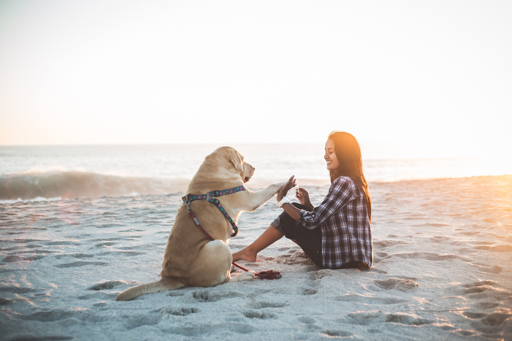

Reasoning:
Alright, let me try to describe this image. There's a scene with a woman and a dog on the beach. The woman is sitting on the sand and has a plaid shirt on, with long hair. She's holding the dog's hand, which is in her lap. The dog is sitting next to her, and it looks like it has a harness on. The beach is in the foreground, and the ocean is in the background. The sun seems to be setting, as there's a warm glow in the sky.

Now, to put this into a clear and concise description:

The image shows a serene beach scene at sunset. A woman with long hair and wearing a plaid shirt is sitting on the sand. She is holding the hand of a golden retriever, which is also sitting on the sand next to her. The dog is wearing a harness. The ocean waves are visible in the background, and the sky is glowing with the warm light of the setting sun.

Answer:
The image depicts a peaceful beach scene at sunset. A woman with long hair, dressed in a plaid shirt, is seated on the sand. She is holding th

In [11]:
def strip_terminal_tokens(text, tokenizer):
    for token in (tokenizer.bos_token, tokenizer.eos_token, tokenizer.pad_token):
        if token:
            text = text.replace(token, "")
    return text.strip()


def split_reasoning_output(text, tokenizer):
    think_start = "[THINK]"
    think_end = "[/THINK]"
    end_pos = text.find(think_end)
    if end_pos < 0:
        return None, strip_terminal_tokens(text.replace(think_start, ""), tokenizer)

    start_pos = text.find(think_start)
    reasoning_start = start_pos + len(think_start) if start_pos >= 0 else 0
    reasoning = strip_terminal_tokens(text[reasoning_start:end_pos], tokenizer)
    answer = strip_terminal_tokens(text[end_pos + len(think_end) :], tokenizer)
    return reasoning, answer


generation_kwargs = (
    {"do_sample": True, "temperature": 0.7, "top_p": 0.95, "max_new_tokens": 1024} if is_reasoning_model else {"do_sample": False, "max_new_tokens": 128}
)
output_ids = model.generate(**inputs, **generation_kwargs)
prompt_length = inputs["input_ids"].shape[-1]
generated_text = processor.tokenizer.decode(output_ids[0, prompt_length:], skip_special_tokens=not is_reasoning_model)
reasoning, answer = split_reasoning_output(generated_text, processor.tokenizer)

print(f"Question:\n{text_message}")
display(image)
if reasoning:
    print(f"Reasoning:\n{reasoning}\n")
print(f"Answer:\n{answer}")

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Try a multi-turn conversation with the model. Upload one or more images, enter a question, and submit it. For the Reasoning checkpoint, the demo displays `[THINK]...[/THINK]` content in a collapsible section and keeps the structured reasoning trace in subsequent model context.

In [12]:
if not Path("gradio_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/notebooks/ministral-3/gradio_helper.py")
    open("gradio_helper.py", "w").write(r.text)